In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [7]:
# 1. LOAD DATASET
url = "https://github.com/ShehrozGhouri/Developers-Hub-DataScience-Internship/raw/refs/heads/main/Task%203%20--%20Customer%20Churn%20Prediction%20Project/Bank%20Churn%20Modelling.csv"
df = pd.read_csv(url)
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,Num Of Products,Has Credit Card,Is Active Member,Estimated Salary,Churn
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Model Accuracy: 86.83%


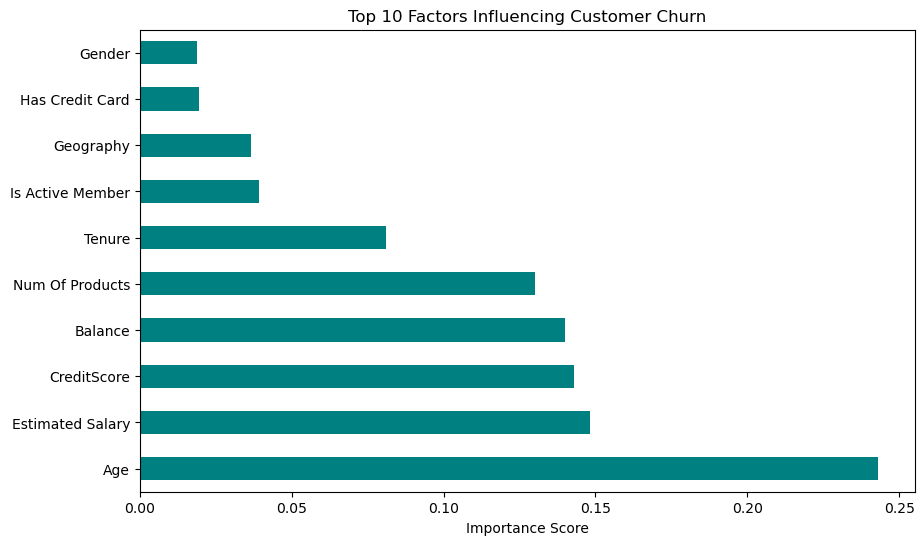

In [26]:
# STEP 2: CLEANING droping useless columns
cols_to_drop = ['CustomerId', 'Surname']

# This code only drops the columns if they are present in the dataframe
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# STEP 3: ENCODING
# Converting 'Gender' and 'Geography' into numbers so the model can understand them
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Geography'] = le.fit_transform(df['Geography'])

# STEP 4: TRAINING THE MODEL
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split the data (70% for training, 30% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Using Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Calculate accuracy
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%")


# STEP 5: FEATURE IMPORTANCE
# This visualizes what influences a customer to leave the bank
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Factors Influencing Customer Churn')
plt.xlabel('Importance Score')
plt.show()

In [27]:
import joblib

# Save the trained model to a file named 'Customer_Chrun_Prediction.pkl'
joblib.dump(model, 'Customer_Chrun_Prediction.pkl')

print("Model saved successfully as Customer_Chrun_Model.pkl!")

Model saved successfully as Customer_Chrun_Model.pkl!
